# Deep Learning with PyTorch Step-by-Step: A Beginner's Guide

# Putting It All Together
Código adaptado do Deep Learning with PyTorch Step-by-Step: A Beginner's Guide by Daniel Voigt Godoy

## Bibliotecas e Importações

In [ ]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [ ]:
try:
    import google.colab
    import requests
    url = 'https://raw.githubusercontent.com/dvgodoy/PyTorchStepByStep/master/config.py'
    r = requests.get(url, allow_redirects=True)
    open('config.py', 'wb').write(r.content)
except ModuleNotFoundError:
    pass

from config import *
config_chapter6()
# This is needed to render the plots in this chapter
from plots.chapter6 import *

Finished!


In [ ]:
import numpy as np
from PIL import Image
from copy import deepcopy

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from torchvision.transforms.v2 import Compose, ToImage, Normalize, \
ToPILImage, Resize, ToDtype
from torchvision.datasets import ImageFolder
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, \
MultiStepLR, CyclicLR, LambdaLR
from torchvision import transforms, datasets

from stepbystep.v2 import StepByStep

## Model StepByStep e CNN2
O modelo StepByStep utilizado foi carregado juntamente com as bibliotecas e desenvolvido pelo autor do livro. O modelo CNN abaixo:

In [ ]:
class CNN2(nn.Module):
    def __init__(self, n_feature, p=0.0):
        super(CNN2, self).__init__()
        self.n_feature = n_feature
        self.p = p
        # Creates the convolution layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_feature, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=n_feature, out_channels=n_feature, kernel_size=3)
        # Creates the linear layers
        # The output size after the convolutions and pooling is not 5x5
        # We need to calculate the correct output size.
        # Assuming input size of 32x32 (CIFAR-10)
        # After conv1: (32-3+2*0)/1 + 1 = 30  # padding=0, stride=1
        # After pool1: 30/2 = 15
        # After conv2: (15-3+2*0)/1 + 1 = 13 # padding=0, stride=1
        # After pool2: 13/2 = 6 (rounded down)

        # So the output size is n_feature x 6 x 6
        self.fc1 = nn.Linear(n_feature * 6 * 6, 50)  # Changed from 5 * 5 to 6 * 6
        # Changed output to 10 for 10 classes
        self.fc2 = nn.Linear(50, 10)  # Changed from 3 to 10
        # Creates dropout layers
        self.drop = nn.Dropout(self.p)

    def featurizer(self, x):
        # Featurizer
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = nn.Flatten()(x)
        return x

    def classifier(self, x):
        # Classifier
        if self.p > 0:
            x = self.drop(x)
        x = self.fc1(x)
        x = F.relu(x)

        if self.p > 0:
            x = self.drop(x)
        x = self.fc2(x)  # Output layer now has 10 units
        return x

    def forward(self, x):
        x = self.featurizer(x)
        x = self.classifier(x)
        return x

## EWMA


In [ ]:
def EWMA(past_value, current_value, alpha):
    return (1 - alpha) * past_value + alpha * current_value

In [ ]:
def calc_ewma(values, period):
    alpha = 2 / (period + 1)
    result = []
    for v in values:
        try:
            prev_value = result[-1]
        except IndexError:
            prev_value = 0

        new_value = EWMA(prev_value, v, alpha)
        result.append(new_value)
    return np.array(result)

In [ ]:
def correction(averaged_value, beta, steps):
    return averaged_value / (1 - (beta ** steps))

In [ ]:
def calc_corrected_ewma(values, period):
    ewma = calc_ewma(values, period)

    alpha = 2 / (period + 1)
    beta = 1 - alpha

    result = []
    for step, v in enumerate(ewma):
        adj_value = correction(v, beta, step + 1)
        result.append(adj_value)

    return np.array(result)

## Capturando parâmetros e gradientes, através de hooks
 e criando os atributos no modelo para criar os schedulers


In [ ]:
# Capturando os parâmetros (by Daniel Godoy, from Deep Learning with PyTorch Step-by-Step: A Beginner's Guide's Chapter 6 notebook)
setattr(StepByStep, '_parameters', {})

def capture_parameters(self, layers_to_hook):
    if not isinstance(layers_to_hook, list):
        layers_to_hook = [layers_to_hook]

    modules = list(self.model.named_modules())
    layer_names = {layer: name for name, layer in modules}

    self._parameters = {}

    for name, layer in modules:
        if name in layers_to_hook:
            self._parameters.update({name: {}})
            for parm_id, p in layer.named_parameters():
                self._parameters[name].update({parm_id: []})

    def fw_hook_fn(layer, inputs, outputs):
        name = layer_names[layer]
        for parm_id, parameter in layer.named_parameters():
            self._parameters[name][parm_id].append(parameter.tolist())

    self.attach_hooks(layers_to_hook, fw_hook_fn)
    return

setattr(StepByStep, 'capture_parameters', capture_parameters)

In [ ]:
# Capturando os gradientes (by Daniel Godoy, from Deep Learning with PyTorch Step-by-Step: A Beginner's Guide's Chapter 6 notebook)
setattr(StepByStep, '_gradients', {})

def capture_gradients(self, layers_to_hook):
    if not isinstance(layers_to_hook, list):
        layers_to_hook = [layers_to_hook]

    modules = list(self.model.named_modules())
    self._gradients = {}

    def make_log_fn(name, parm_id):
        def log_fn(grad):
            self._gradients[name][parm_id].append(grad.tolist())
            return
        return log_fn

    for name, layer in self.model.named_modules():
        if name in layers_to_hook:
            self._gradients.update({name: {}})
            for parm_id, p in layer.named_parameters():
                if p.requires_grad:
                    self._gradients[name].update({parm_id: []})
                    log_fn = make_log_fn(name, parm_id)
                    self.handles[f'{name}.{parm_id}.grad'] = p.register_hook(log_fn)
    return

setattr(StepByStep, 'capture_gradients', capture_gradients)

In [ ]:
setattr(StepByStep, 'scheduler', None)
setattr(StepByStep, 'is_batch_lr_scheduler', False)

def set_lr_scheduler(self, scheduler):
    # Makes sure the scheduler in the argument is assigned to the
    # optimizer we're using in this class
    if scheduler.optimizer == self.optimizer:
        self.scheduler = scheduler
        if (isinstance(scheduler, optim.lr_scheduler.CyclicLR) or
            isinstance(scheduler, optim.lr_scheduler.OneCycleLR) or
            isinstance(scheduler, optim.lr_scheduler.CosineAnnealingWarmRestarts)):
            self.is_batch_lr_scheduler = True
        else:
            self.is_batch_lr_scheduler = False

setattr(StepByStep, 'set_lr_scheduler', set_lr_scheduler)
setattr(StepByStep, 'learning_rates', [])

def _epoch_schedulers(self, val_loss):
    if self.scheduler:
        if not self.is_batch_lr_scheduler:
            if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                self.scheduler.step(val_loss)
            else:
                self.scheduler.step()

            current_lr = list(map(lambda d: d['lr'], self.scheduler.optimizer.state_dict()['param_groups']))
            self.learning_rates.append(current_lr)

setattr(StepByStep, '_epoch_schedulers', _epoch_schedulers)
def train(self, n_epochs, seed=42):
    # To ensure reproducibility of the training process
    self.set_seed(seed)

    for epoch in range(n_epochs):
        # Keeps track of the numbers of epochs
        # by updating the corresponding attribute
        self.total_epochs += 1

        # inner loop
        # Performs training using mini-batches
        loss = self._mini_batch(validation=False)
        self.losses.append(loss)

        # VALIDATION
        # no gradients in validation!
        with torch.no_grad():
            # Performs evaluation using mini-batches
            val_loss = self._mini_batch(validation=True)
            self.val_losses.append(val_loss)

        self._epoch_schedulers(val_loss)

        # If a SummaryWriter has been set...
        if self.writer:
            scalars = {'training': loss}
            if val_loss is not None:
                scalars.update({'validation': val_loss})
            # Records both losses for each epoch under the main tag "loss"
            self.writer.add_scalars(main_tag='loss',
                                    tag_scalar_dict=scalars,
                                    global_step=epoch)

    if self.writer:
        # Closes the writer
        self.writer.close()

setattr(StepByStep, 'train', train)
def make_lr_fn(start_lr, end_lr, num_iter, step_mode='exp'):
    if step_mode == 'linear':
        factor = (end_lr / start_lr - 1) / num_iter
        def lr_fn(iteration):
            return 1 + iteration * factor
    else:
        factor = (np.log(end_lr) - np.log(start_lr)) / num_iter
        def lr_fn(iteration):
            return np.exp(factor)**iteration
    return lr_fn
def lr_range_test(self, data_loader, end_lr, num_iter=100, step_mode='exp', alpha=0.05, ax=None):
    # Since the test updates both model and optimizer we need to store
    # their initial states to restore them in the end
    previous_states = {'model': deepcopy(self.model.state_dict()),
                       'optimizer': deepcopy(self.optimizer.state_dict())}
    # Retrieves the learning rate set in the optimizer
    start_lr = self.optimizer.state_dict()['param_groups'][0]['lr']

    # Builds a custom function and corresponding scheduler
    lr_fn = make_lr_fn(start_lr, end_lr, num_iter)
    scheduler = LambdaLR(self.optimizer, lr_lambda=lr_fn)

    # Variables for tracking results and iterations
    tracking = {'loss': [], 'lr': []}
    iteration = 0

    # If there are more iterations than mini-batches in the data loader,
    # it will have to loop over it more than once
    while (iteration < num_iter):
        # That's the typical mini-batch inner loop
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)
            # Step 1
            yhat = self.model(x_batch)
            # Step 2
            loss = self.loss_fn(yhat, y_batch)
            # Step 3
            loss.backward()

            # Here we keep track of the losses (smoothed)
            # and the learning rates
            tracking['lr'].append(scheduler.get_last_lr()[0])
            if iteration == 0:
                tracking['loss'].append(loss.item())
            else:
                prev_loss = tracking['loss'][-1]
                smoothed_loss = alpha * loss.item() + (1-alpha) * prev_loss
                tracking['loss'].append(smoothed_loss)

            iteration += 1
            # Number of iterations reached
            if iteration == num_iter:
                break

            # Step 4
            self.optimizer.step()
            scheduler.step()
            self.optimizer.zero_grad()

    # Restores the original states
    self.optimizer.load_state_dict(previous_states['optimizer'])
    self.model.load_state_dict(previous_states['model'])

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    else:
        fig = ax.get_figure()
    ax.plot(tracking['lr'], tracking['loss'])
    if step_mode == 'exp':
        ax.set_xscale('log')
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Loss')
    fig.tight_layout()
    return tracking, fig

setattr(StepByStep, 'lr_range_test', lr_range_test)
def set_optimizer(self, optimizer):
    self.optimizer = optimizer

setattr(StepByStep, 'set_optimizer', set_optimizer)

## Geração e preparação de dados


In [ ]:
# Configuração do dataset (CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Fixando a semente para garantir reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)
tdataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
vdataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(tdataset, batch_size=64, shuffle=False)  # shuffle=False para ordem fixa
val_loader = torch.utils.data.DataLoader(vdataset, batch_size=64, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
torch.manual_seed(42)
model_cnn3 = CNN2(n_feature=5, p=0.5)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_cnn3 = optim.SGD(model_cnn3.parameters(), lr=1e-3, momentum=0.9, nesterov=True)

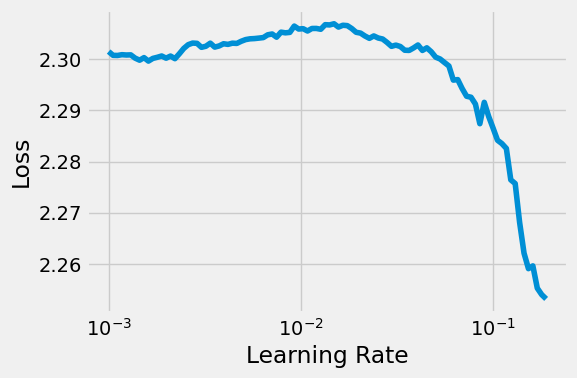

In [ ]:
sbs_cnn3 = StepByStep(model_cnn3, multi_loss_fn, optimizer_cnn3)
tracking, fig = sbs_cnn3.lr_range_test(train_loader, end_lr=2e-1, num_iter=100)

In [ ]:
optimizer_cnn3 = optim.SGD(model_cnn3.parameters(), lr=0.1, momentum=0.9, nesterov=True)
sbs_cnn3.set_optimizer(optimizer_cnn3)

scheduler = CyclicLR(optimizer_cnn3, base_lr=1e-2, max_lr=0.1, step_size_up=len(train_loader), mode='triangular2')
sbs_cnn3.set_lr_scheduler(scheduler)

In [ ]:
sbs_cnn3.set_loaders(train_loader, val_loader)
sbs_cnn3.train(10)

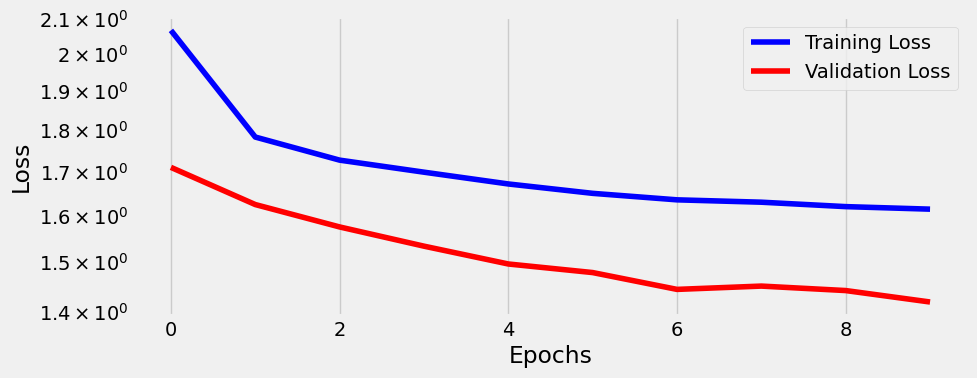

In [ ]:
fig = sbs_cnn3.plot_losses()

In [ ]:
print(StepByStep.loader_apply(train_loader, sbs_cnn3.correct).sum(axis=0),
      StepByStep.loader_apply(val_loader, sbs_cnn3.correct).sum(axis=0))

tensor([25069, 50000]) tensor([ 4932, 10000])


Testando com apenas 3 classes (avião, carro ou caminhão)

In [ ]:
t_indices = [i for i, (_, label) in enumerate(tdataset) if label in [0, 1, 9]]
label_mapping = {0: 0, 1: 1, 9: 2}
t_dataset = Subset(tdataset, t_indices)
t_dataset.dataset.targets = [label_mapping.get(label, label)
                        for label in t_dataset.dataset.targets]
t_dataset.dataset.targets = [label_mapping.get(label, label) if idx in t_indices else label
                          for idx, label in enumerate(t_dataset.dataset.targets)]

v_indices = [i for i, (_, label) in enumerate(vdataset) if label in [0, 1, 9]]
v_dataset = Subset(vdataset, v_indices)
v_dataset.dataset.targets = [label_mapping.get(label, label)
                            for label in v_dataset.dataset.targets]
v_dataset.dataset.targets = [label_mapping.get(label, label) if idx in v_indices else label
                          for idx, label in enumerate(v_dataset.dataset.targets)]

train_loader = torch.utils.data.DataLoader(t_dataset, batch_size=64, shuffle=False)
val_loader = torch.utils.data.DataLoader(v_dataset, batch_size=64, shuffle=False)

In [ ]:
# CNN2 PARA 3 CLASSES NOVAMENTE
class CNN2(nn.Module):
    def __init__(self, n_feature, p=0.0):
        super(CNN2, self).__init__()
        self.n_feature = n_feature
        self.p = p
        # Creates the convolution layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_feature, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=n_feature, out_channels=n_feature, kernel_size=3)
        # Creates the linear layers
        # The output size after the convolutions and pooling is not 5x5
        # We need to calculate the correct output size.
        # Assuming input size of 32x32 (CIFAR-10)
        # After conv1: (32-3+2*0)/1 + 1 = 30  # padding=0, stride=1
        # After pool1: 30/2 = 15
        # After conv2: (15-3+2*0)/1 + 1 = 13 # padding=0, stride=1
        # After pool2: 13/2 = 6 (rounded down)

        # So the output size is n_feature x 6 x 6
        self.fc1 = nn.Linear(n_feature * 6 * 6, 50)  # Changed from 5 * 5 to 6 * 6
        # Changed output to 10 for 10 classes
        self.fc2 = nn.Linear(50, 3)  # Changed from 3 to 10
        # Creates dropout layers
        self.drop = nn.Dropout(self.p)

    def featurizer(self, x):
        # Featurizer
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = nn.Flatten()(x)
        return x

    def classifier(self, x):
        # Classifier
        if self.p > 0:
            x = self.drop(x)
        x = self.fc1(x)
        x = F.relu(x)

        if self.p > 0:
            x = self.drop(x)
        x = self.fc2(x)  # Output layer now has 10 units
        return x

    def forward(self, x):
        x = self.featurizer(x)
        x = self.classifier(x)
        return x

# Aplicando
torch.manual_seed(42)
model_cnn3 = CNN2(n_feature=5, p=0.5)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_cnn3 = optim.SGD(model_cnn3.parameters(), lr=1e-3, momentum=0.9, nesterov=True)


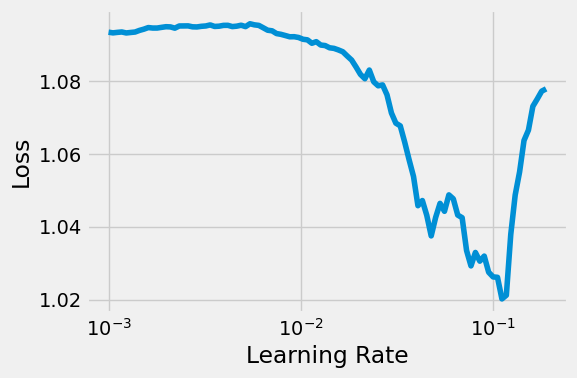

In [ ]:
sbs_cnn3 = StepByStep(model_cnn3, multi_loss_fn, optimizer_cnn3)
tracking, fig = sbs_cnn3.lr_range_test(train_loader, end_lr=2e-1, num_iter=100)

In [ ]:
optimizer_cnn3 = optim.SGD(model_cnn3.parameters(), lr=0.05, momentum=0.9, nesterov=True)
sbs_cnn3.set_optimizer(optimizer_cnn3)
scheduler = CyclicLR(optimizer_cnn3, base_lr=1e-2, max_lr=0.05, step_size_up=len(train_loader), mode='triangular2')
sbs_cnn3.set_lr_scheduler(scheduler)
sbs_cnn3.set_loaders(train_loader, val_loader)
sbs_cnn3.train(10)


tensor([11591, 15000]) tensor([2309, 3000])


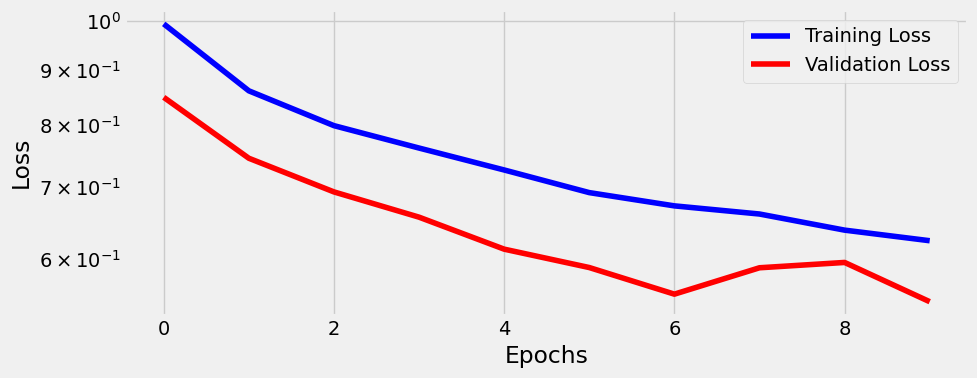

In [ ]:
fig = sbs_cnn3.plot_losses()
print(StepByStep.loader_apply(train_loader, sbs_cnn3.correct).sum(axis=0),
      StepByStep.loader_apply(val_loader, sbs_cnn3.correct).sum(axis=0))